<a href="https://colab.research.google.com/github/marckeynesujanto-hub/Tugas-BigDataProcessing/blob/main/Walmart_BigData_PySpark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Checkpoint dari pipeline
1. Environment Setup
2. Data Loading & Exploration
3. Data Cleaning & Transformation
4. Feature Engineering
5. Descriptive Analytics
6. Machine Learning — Regression (Linear Regression)
7. Visualization


## 1. Environment Setup

In [ ]:
# Install PySpark in Colab
!pip install pyspark --quiet
!pip install matplotlib seaborn --quiet

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np

# Initialize SparkSession
spark = SparkSession.builder \
    .appName("WalmartSalesForecasting") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(f"Spark version: {spark.version}")
print("SparkSession initialized successfully ✅")

Spark version: 4.0.2
SparkSession initialized successfully ✅


## 2. Data Loading & Exploration
test, train, stores, features


In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

In [ ]:
import os

DATA_PATH = '/content/'

# Load all datasets
df_stores   = spark.read.csv(os.path.join(DATA_PATH, 'stores - Walmart Sales Forecast.csv'),   header=True, inferSchema=True)
df_train    = spark.read.csv(os.path.join(DATA_PATH, 'train - Walmart Sales Forecast.csv'),    header=True, inferSchema=True)
df_features = spark.read.csv(os.path.join(DATA_PATH, 'features - Walmart Sales Forecast.csv'), header=True, inferSchema=True)

print("=== STORES ===")
df_stores.printSchema()
df_stores.show(5)

print("=== TRAIN ===")
df_train.printSchema()
df_train.show(5)

print("=== FEATURES ===")
df_features.printSchema()
df_features.show(5)

=== STORES ===
root
 |-- Store: integer (nullable = true)
 |-- Type: string (nullable = true)
 |-- Size: integer (nullable = true)

+-----+----+------+
|Store|Type|  Size|
+-----+----+------+
|    1|   A|151315|
|    2|   A|202307|
|    3|   B| 37392|
|    4|   A|205863|
|    5|   B| 34875|
+-----+----+------+
only showing top 5 rows
=== TRAIN ===
root
 |-- Store: integer (nullable = true)
 |-- Dept: integer (nullable = true)
 |-- Date: date (nullable = true)
 |-- Weekly_Sales: double (nullable = true)
 |-- IsHoliday: boolean (nullable = true)

+-----+----+----------+------------+---------+
|Store|Dept|      Date|Weekly_Sales|IsHoliday|
+-----+----+----------+------------+---------+
|    1|   1|2010-02-05|     24924.5|    false|
|    1|   1|2010-02-12|    46039.49|     true|
|    1|   1|2010-02-19|    41595.55|    false|
|    1|   1|2010-02-26|    19403.54|    false|
|    1|   1|2010-03-05|     21827.9|    false|
+-----+----+----------+------------+---------+
only showing top 5 rows
==

In [ ]:
print(f"Stores   rows: {df_stores.count():,}")
print(f"Train    rows: {df_train.count():,}")
print(f"Features rows: {df_features.count():,}")

Stores   rows: 45
Train    rows: 421,570
Features rows: 8,190


## 3. Data Cleaning & Transformation

In [ ]:
# ── 3.1 Check for nulls ──
print("=== NULL counts in TRAIN ===")
df_train.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df_train.columns
]).show()

print("=== NULL counts in FEATURES ===")
df_features.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df_features.columns
]).show()

=== NULL counts in TRAIN ===
+-----+----+----+------------+---------+
|Store|Dept|Date|Weekly_Sales|IsHoliday|
+-----+----+----+------------+---------+
|    0|   0|   0|           0|        0|
+-----+----+----+------------+---------+

=== NULL counts in FEATURES ===
+-----+----+-----------+----------+---------+---------+---------+---------+---------+---+------------+---------+
|Store|Date|Temperature|Fuel_Price|MarkDown1|MarkDown2|MarkDown3|MarkDown4|MarkDown5|CPI|Unemployment|IsHoliday|
+-----+----+-----------+----------+---------+---------+---------+---------+---------+---+------------+---------+
|    0|   0|          0|         0|        0|        0|        0|        0|        0|  0|           0|        0|
+-----+----+-----------+----------+---------+---------+---------+---------+---------+---+------------+---------+



In [ ]:
# ── 3.2 Clean TRAIN: remove negative weekly sales (returns/errors) ──
df_train_clean = df_train.filter(F.col('Weekly_Sales') >= 0)

removed = df_train.count() - df_train_clean.count()
print(f"Removed {removed:,} rows with negative Weekly_Sales")

# ── 3.3 Parse Date column ──
df_train_clean = df_train_clean.withColumn(
    'Date', F.to_date(F.col('Date'), 'yyyy-MM-dd')
)
df_features_clean = df_features.withColumn(
    'Date', F.to_date(F.col('Date'), 'yyyy-MM-dd')
)

# ── 3.4 Cast ALL columns in features explicitly ──
df_features_clean = df_features_clean \
    .withColumn('Store',        F.col('Store').cast('int')) \
    .withColumn('Temperature',  F.when(F.col('Temperature')  == 'NA', None).otherwise(F.col('Temperature')).cast('float')) \
    .withColumn('Fuel_Price',   F.when(F.col('Fuel_Price')   == 'NA', None).otherwise(F.col('Fuel_Price')).cast('float')) \
    .withColumn('MarkDown1',    F.when(F.col('MarkDown1')    == 'NA', None).otherwise(F.col('MarkDown1')).cast('float')) \
    .withColumn('MarkDown2',    F.when(F.col('MarkDown2')    == 'NA', None).otherwise(F.col('MarkDown2')).cast('float')) \
    .withColumn('MarkDown3',    F.when(F.col('MarkDown3')    == 'NA', None).otherwise(F.col('MarkDown3')).cast('float')) \
    .withColumn('MarkDown4',    F.when(F.col('MarkDown4')    == 'NA', None).otherwise(F.col('MarkDown4')).cast('float')) \
    .withColumn('MarkDown5',    F.when(F.col('MarkDown5')    == 'NA', None).otherwise(F.col('MarkDown5')).cast('float')) \
    .withColumn('CPI',          F.when(F.col('CPI')          == 'NA', None).otherwise(F.col('CPI')).cast('float')) \
    .withColumn('Unemployment', F.when(F.col('Unemployment') == 'NA', None).otherwise(F.col('Unemployment')).cast('float'))

# Fill markdown nulls with 0
markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']
df_features_clean = df_features_clean.fillna(0, subset=markdown_cols)

print("Data cleaning complete ✅")

Removed 1,285 rows with negative Weekly_Sales
Data cleaning complete ✅


## 4. Feature Engineering

In [ ]:
# Reload features with inferSchema=False and clean immediately
df_features = spark.read.csv(DATA_PATH + 'features - Walmart Sales Forecast.csv',
                              header=True, inferSchema=False)

df_features_clean = df_features.withColumn(
    'Date', F.to_date(F.col('Date'), 'yyyy-MM-dd')
) \
    .withColumn('Store',        F.col('Store').cast('int')) \
    .withColumn('Temperature',  F.when(F.col('Temperature')  == 'NA', None).otherwise(F.col('Temperature')).cast('float')) \
    .withColumn('Fuel_Price',   F.when(F.col('Fuel_Price')   == 'NA', None).otherwise(F.col('Fuel_Price')).cast('float')) \
    .withColumn('MarkDown1',    F.when(F.col('MarkDown1')    == 'NA', None).otherwise(F.col('MarkDown1')).cast('float')) \
    .withColumn('MarkDown2',    F.when(F.col('MarkDown2')    == 'NA', None).otherwise(F.col('MarkDown2')).cast('float')) \
    .withColumn('MarkDown3',    F.when(F.col('MarkDown3')    == 'NA', None).otherwise(F.col('MarkDown3')).cast('float')) \
    .withColumn('MarkDown4',    F.when(F.col('MarkDown4')    == 'NA', None).otherwise(F.col('MarkDown4')).cast('float')) \
    .withColumn('MarkDown5',    F.when(F.col('MarkDown5')    == 'NA', None).otherwise(F.col('MarkDown5')).cast('float')) \
    .withColumn('CPI',          F.when(F.col('CPI')          == 'NA', None).otherwise(F.col('CPI')).cast('float')) \
    .withColumn('Unemployment', F.when(F.col('Unemployment') == 'NA', None).otherwise(F.col('Unemployment')).cast('float')) \
    .drop('IsHoliday')

df_features_clean = df_features_clean.fillna(0, subset=['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5'])

print("Features reloaded and cleaned ✅")
df_features_clean.printSchema()

Features reloaded and cleaned ✅
root
 |-- Store: integer (nullable = true)
 |-- Date: date (nullable = true)
 |-- Temperature: float (nullable = true)
 |-- Fuel_Price: float (nullable = true)
 |-- MarkDown1: float (nullable = false)
 |-- MarkDown2: float (nullable = false)
 |-- MarkDown3: float (nullable = false)
 |-- MarkDown4: float (nullable = false)
 |-- MarkDown5: float (nullable = false)
 |-- CPI: float (nullable = true)
 |-- Unemployment: float (nullable = true)



In [ ]:
# ── 4.1 Join all datasets ──
# Drop duplicate IsHoliday from features (already exists in train)
df_features_clean = df_features_clean.drop('IsHoliday')

df = df_train_clean \
    .join(df_stores, on='Store', how='left') \
    .join(df_features_clean, on=['Store','Date'], how='left')

print(f"Joined dataset rows: {df.count():,}")
df.show(3)

Joined dataset rows: 420,285
+-----+----------+----+------------+---------+----+------+-----------+----------+---------+---------+---------+---------+---------+---------+------------+
|Store|      Date|Dept|Weekly_Sales|IsHoliday|Type|  Size|Temperature|Fuel_Price|MarkDown1|MarkDown2|MarkDown3|MarkDown4|MarkDown5|      CPI|Unemployment|
+-----+----------+----+------------+---------+----+------+-----------+----------+---------+---------+---------+---------+---------+---------+------------+
|    1|2010-02-05|   1|     24924.5|    false|   A|151315|      42.31|     2.572|      0.0|      0.0|      0.0|      0.0|      0.0|211.09636|       8.106|
|    1|2010-02-12|   1|    46039.49|     true|   A|151315|      38.51|     2.548|      0.0|      0.0|      0.0|      0.0|      0.0|211.24217|       8.106|
|    1|2010-02-19|   1|    41595.55|    false|   A|151315|      39.93|     2.514|      0.0|      0.0|      0.0|      0.0|      0.0|211.28914|       8.106|
+-----+----------+----+------------+-----

In [ ]:
# ── 4.2 Extract temporal features ──
df = df \
    .withColumn('Year',        F.year('Date')) \
    .withColumn('Month',       F.month('Date')) \
    .withColumn('Week',        F.weekofyear('Date')) \
    .withColumn('DayOfYear',   F.dayofyear('Date')) \
    .withColumn('Quarter',     F.quarter('Date'))

# ── 4.3 Holiday flag (already in dataset as IsHoliday bool → cast to int) ──
df = df.withColumn('IsHoliday_int', F.col('IsHoliday').cast('int'))

# ── 4.4 Total markdowns per row ──
df = df.withColumn(
    'TotalMarkdown',
    F.col('MarkDown1') + F.col('MarkDown2') + F.col('MarkDown3') +
    F.col('MarkDown4') + F.col('MarkDown5')
)

# ── 4.5 Encode Store Type (A/B/C → numeric index) ──
indexer = StringIndexer(inputCol='Type', outputCol='TypeIndex')
df = indexer.fit(df).transform(df)

# ── 4.6 Lag feature: previous week sales per Store+Dept ──
window_spec = Window.partitionBy('Store', 'Dept').orderBy('Date')
df = df.withColumn('Prev_Week_Sales', F.lag('Weekly_Sales', 1).over(window_spec))
df = df.fillna(0, subset=['Prev_Week_Sales'])

print("Feature engineering complete ✅")
df.select('Store','Dept','Date','Weekly_Sales','Year','Month','Week',
          'IsHoliday_int','TotalMarkdown','TypeIndex','Prev_Week_Sales').show(5)

Feature engineering complete ✅
+-----+----+----------+------------+----+-----+----+-------------+-------------+---------+---------------+
|Store|Dept|      Date|Weekly_Sales|Year|Month|Week|IsHoliday_int|TotalMarkdown|TypeIndex|Prev_Week_Sales|
+-----+----+----------+------------+----+-----+----+-------------+-------------+---------+---------------+
|    1|   3|2010-02-05|    13740.12|2010|    2|   5|            0|          0.0|      0.0|            0.0|
|    1|   3|2010-02-12|    10887.84|2010|    2|   6|            1|          0.0|      0.0|       13740.12|
|    1|   3|2010-02-19|    11523.47|2010|    2|   7|            0|          0.0|      0.0|       10887.84|
|    1|   3|2010-02-26|    11135.17|2010|    2|   8|            0|          0.0|      0.0|       11523.47|
|    1|   3|2010-03-05|    12275.58|2010|    3|   9|            0|          0.0|      0.0|       11135.17|
+-----+----+----------+------------+----+-----+----+-------------+-------------+---------+---------------+
only s

## 5. Descriptive Analytics

In [ ]:
# ── 5.1 Summary statistics ──
print("=== Summary Statistics: Weekly_Sales ===")
df.select(
    F.round(F.mean('Weekly_Sales'), 2).alias('Mean'),
    F.round(F.stddev('Weekly_Sales'), 2).alias('StdDev'),
    F.round(F.min('Weekly_Sales'), 2).alias('Min'),
    F.round(F.max('Weekly_Sales'), 2).alias('Max'),
    F.round(F.expr('percentile_approx(Weekly_Sales, 0.5)'), 2).alias('Median')
).show()

=== Summary Statistics: Weekly_Sales ===
+--------+-------+---+---------+-------+
|    Mean| StdDev|Min|      Max| Median|
+--------+-------+---+---------+-------+
|16030.33|22728.5|0.0|693099.36|7658.87|
+--------+-------+---+---------+-------+



In [ ]:
# ── 5.2 Total & average sales by Store ──
sales_by_store = df.groupBy('Store') \
    .agg(
        F.round(F.sum('Weekly_Sales'), 2).alias('Total_Sales'),
        F.round(F.avg('Weekly_Sales'), 2).alias('Avg_Sales')
    ).orderBy('Total_Sales', ascending=False)

print("=== Top 10 Stores by Total Sales ===")
sales_by_store.show(10)

=== Top 10 Stores by Total Sales ===
+-----+--------------+---------+
|Store|   Total_Sales|Avg_Sales|
+-----+--------------+---------+
|   20|3.0140138145E8| 29618.85|
|    4| 2.995452693E8| 29175.54|
|   14|2.8900186444E8| 28877.08|
|   13|2.8651795036E8| 27394.39|
|    2| 2.753871555E8| 26956.46|
|   10|2.7162410939E8| 26461.19|
|   27|2.5385718997E8| 24892.84|
|    6|2.2375858834E8| 21958.64|
|    1|2.2240676677E8| 21742.77|
|   39|2.0744649423E8| 21081.96|
+-----+--------------+---------+
only showing top 10 rows


In [ ]:
# ── 5.3 Sales by Store Type ──
sales_by_type = df.groupBy('Type') \
    .agg(
        F.round(F.sum('Weekly_Sales'), 2).alias('Total_Sales'),
        F.round(F.avg('Weekly_Sales'), 2).alias('Avg_Sales'),
        F.count('*').alias('Record_Count')
    ).orderBy('Total_Sales', ascending=False)

print("=== Sales by Store Type ===")
sales_by_type.show()

# ── 5.4 Holiday vs Non-Holiday sales ──
holiday_impact = df.groupBy('IsHoliday') \
    .agg(
        F.round(F.avg('Weekly_Sales'), 2).alias('Avg_Sales'),
        F.count('*').alias('Count')
    )

print("=== Holiday Impact on Sales ===")
holiday_impact.show()

# ── 5.5 Monthly sales trend ──
monthly_sales = df.groupBy('Year','Month') \
    .agg(F.round(F.sum('Weekly_Sales'), 2).alias('Total_Sales')) \
    .orderBy('Year','Month')

print("=== Monthly Sales Trend ===")
monthly_sales.show(24)

=== Sales by Store Type ===
+----+---------------+---------+------------+
|Type|    Total_Sales|Avg_Sales|Record_Count|
+----+---------------+---------+------------+
|   A|4.33105747853E9| 20145.11|      214993|
|   B|2.00074164834E9| 12288.13|      162819|
|   C|  4.055080218E8|  9547.43|       42473|
+----+---------------+---------+------------+

=== Holiday Impact on Sales ===
+---------+---------+------+
|IsHoliday|Avg_Sales| Count|
+---------+---------+------+
|     true| 17092.57| 29563|
|    false| 15949.96|390722|
+---------+---------+------+

=== Monthly Sales Trend ===
+----+-----+--------------+
|Year|Month|   Total_Sales|
+----+-----+--------------+
|2010|    2|1.9033601906E8|
|2010|    3| 1.819235714E8|
|2010|    4|2.3141399743E8|
|2010|    5|1.8671159507E8|
|2010|    6|1.9224691244E8|
|2010|    7|2.3258265633E8|
|2010|    8|1.8764155797E8|
|2010|    9|  1.77271696E8|
|2010|   10|2.1716957816E8|
|2010|   11|2.0285517496E8|
|2010|   12| 2.887661242E8|
|2011|    1|1.63705405

In [ ]:
# ── 5.6 Top 10 Departments by average sales ──
dept_sales = df.groupBy('Dept') \
    .agg(F.round(F.avg('Weekly_Sales'), 2).alias('Avg_Sales')) \
    .orderBy('Avg_Sales', ascending=False)

print("=== Top 10 Departments by Avg Sales ===")
dept_sales.show(10)

=== Top 10 Departments by Avg Sales ===
+----+---------+
|Dept|Avg_Sales|
+----+---------+
|  92| 75204.87|
|  95| 69824.42|
|  38| 61090.62|
|  72| 50852.99|
|  65| 45441.71|
|  90| 45232.08|
|  40|  44900.7|
|   2| 43607.02|
|  94| 33864.68|
|  91| 33687.91|
+----+---------+
only showing top 10 rows


## 6. Machine Learning — Regression (Predicting Weekly Sales)

In [ ]:
# ── 6.1 Select features for ML ──
feature_cols = [
    'Store', 'Dept', 'Size', 'TypeIndex',
    'Year', 'Month', 'Week', 'Quarter',
    'IsHoliday_int', 'Temperature', 'Fuel_Price',
    'CPI', 'Unemployment', 'TotalMarkdown',
    'Prev_Week_Sales'
]

# Drop rows with nulls in feature columns
df_ml = df.select(feature_cols + ['Weekly_Sales']).dropna()

print(f"ML-ready dataset rows: {df_ml.count():,}")

# ── 6.2 Assemble feature vector ──
assembler = VectorAssembler(inputCols=feature_cols, outputCol='features')
df_ml = assembler.transform(df_ml)

# ── 6.3 Train/test split (80/20) ──
train_data, test_data = df_ml.randomSplit([0.8, 0.2], seed=42)
print(f"Train: {train_data.count():,} rows | Test: {test_data.count():,} rows")

ML-ready dataset rows: 420,285
Train: 336,152 rows | Test: 84,133 rows


In [ ]:
# ── 6.4 Model A: Linear Regression ──
lr = LinearRegression(
    featuresCol='features',
    labelCol='Weekly_Sales',
    maxIter=20,
    regParam=0.1
)

lr_model = lr.fit(train_data)
lr_preds  = lr_model.transform(test_data)

evaluator_rmse = RegressionEvaluator(labelCol='Weekly_Sales', predictionCol='prediction', metricName='rmse')
evaluator_mae  = RegressionEvaluator(labelCol='Weekly_Sales', predictionCol='prediction', metricName='mae')
evaluator_r2   = RegressionEvaluator(labelCol='Weekly_Sales', predictionCol='prediction', metricName='r2')

lr_rmse = evaluator_rmse.evaluate(lr_preds)
lr_mae  = evaluator_mae.evaluate(lr_preds)
lr_r2   = evaluator_r2.evaluate(lr_preds)

print("=== Linear Regression Results ===")
print(f"  RMSE : {lr_rmse:,.2f}")
print(f"  MAE  : {lr_mae:,.2f}")
print(f"  R²   : {lr_r2:.4f}")

=== Linear Regression Results ===
  RMSE : 7,294.32
  MAE  : 2,501.03
  R²   : 0.8970


In [ ]:
# ── 6.5 Model B: Random Forest Regressor ──
rf = RandomForestRegressor(
    featuresCol='features',
    labelCol='Weekly_Sales',
    numTrees=50,
    maxDepth=10,
    seed=42
)

rf_model = rf.fit(train_data)
rf_preds  = rf_model.transform(test_data)

rf_rmse = evaluator_rmse.evaluate(rf_preds)
rf_mae  = evaluator_mae.evaluate(rf_preds)
rf_r2   = evaluator_r2.evaluate(rf_preds)

print("=== Random Forest Regressor Results ===")
print(f"  RMSE : {rf_rmse:,.2f}")
print(f"  MAE  : {rf_mae:,.2f}")
print(f"  R²   : {rf_r2:.4f}")

=== Random Forest Regressor Results ===
  RMSE : 5,623.24
  MAE  : 2,488.35
  R²   : 0.9388


In [ ]:
# ── 6.6 Model Comparison ──
comparison_data = {
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE':  [round(lr_rmse, 2), round(rf_rmse, 2)],
    'MAE':   [round(lr_mae,  2), round(rf_mae,  2)],
    'R2':    [round(lr_r2,   4), round(rf_r2,   4)]
}
comp_df = pd.DataFrame(comparison_data)
print("=== Model Comparison ===")
print(comp_df.to_string(index=False))

best = 'Random Forest' if rf_r2 > lr_r2 else 'Linear Regression'
print(f"\n✅ Best model: {best}")

=== Model Comparison ===
            Model    RMSE     MAE     R2
Linear Regression 7294.32 2501.03 0.8970
    Random Forest 5623.24 2488.35 0.9388

✅ Best model: Random Forest


In [ ]:
# ── 6.7 Feature Importances (Random Forest) ──
importances = rf_model.featureImportances
feat_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances.toArray()
}).sort_values('Importance', ascending=False)

print("=== Top Feature Importances ===")
print(feat_imp.to_string(index=False))

=== Top Feature Importances ===
        Feature  Importance
Prev_Week_Sales    0.810085
           Dept    0.108246
           Size    0.032911
          Store    0.011088
      TypeIndex    0.010534
           Week    0.009529
            CPI    0.003672
          Month    0.003392
   Unemployment    0.002853
  IsHoliday_int    0.002019
     Fuel_Price    0.001648
    Temperature    0.001592
  TotalMarkdown    0.001438
           Year    0.000565
        Quarter    0.000428


## 7. Visualization

> Convert small aggregations to Pandas for plotting (standard Big Data pattern).

In [ ]:
# ── Collect aggregated data to Pandas ──
pd_store_sales   = sales_by_store.limit(20).toPandas()
pd_type_sales    = sales_by_type.toPandas()
pd_monthly       = monthly_sales.toPandas()
pd_dept_sales    = dept_sales.limit(15).toPandas()
pd_holiday       = holiday_impact.toPandas()
pd_rf_preds      = rf_preds.select('Weekly_Sales','prediction').limit(500).toPandas()

# Create month label
pd_monthly['Month_Label'] = pd_monthly['Year'].astype(str) + '-' + pd_monthly['Month'].astype(str).str.zfill(2)

print("Data collected for visualization ✅")

Data collected for visualization ✅


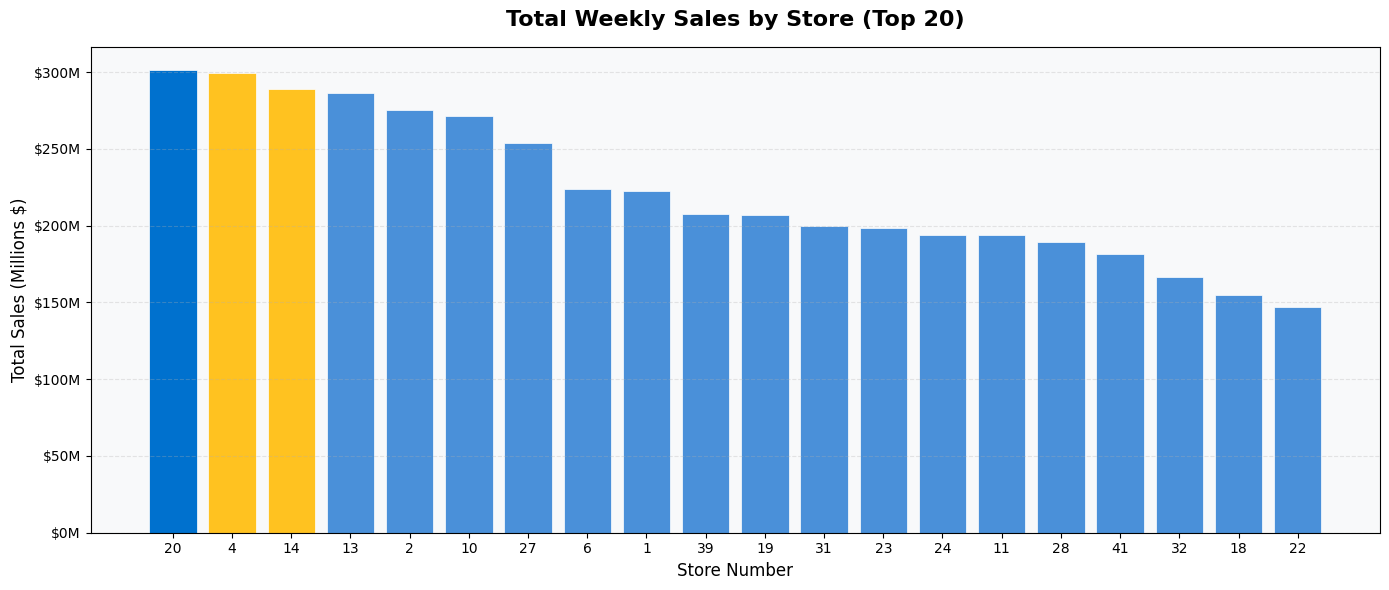

Visualization 1 saved ✅


In [ ]:
# ── Visualization 1: Total Sales by Store (Top 20) ──
fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#0071CE' if i == 0 else '#FFC220' if i < 3 else '#4a90d9'
          for i in range(len(pd_store_sales))]
bars = ax.bar(pd_store_sales['Store'].astype(str), pd_store_sales['Total_Sales'] / 1e6,
              color=colors, edgecolor='white', linewidth=0.5)
ax.set_title('Total Weekly Sales by Store (Top 20)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Store Number', fontsize=12)
ax.set_ylabel('Total Sales (Millions $)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig('viz1_sales_by_store.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 1 saved ✅")

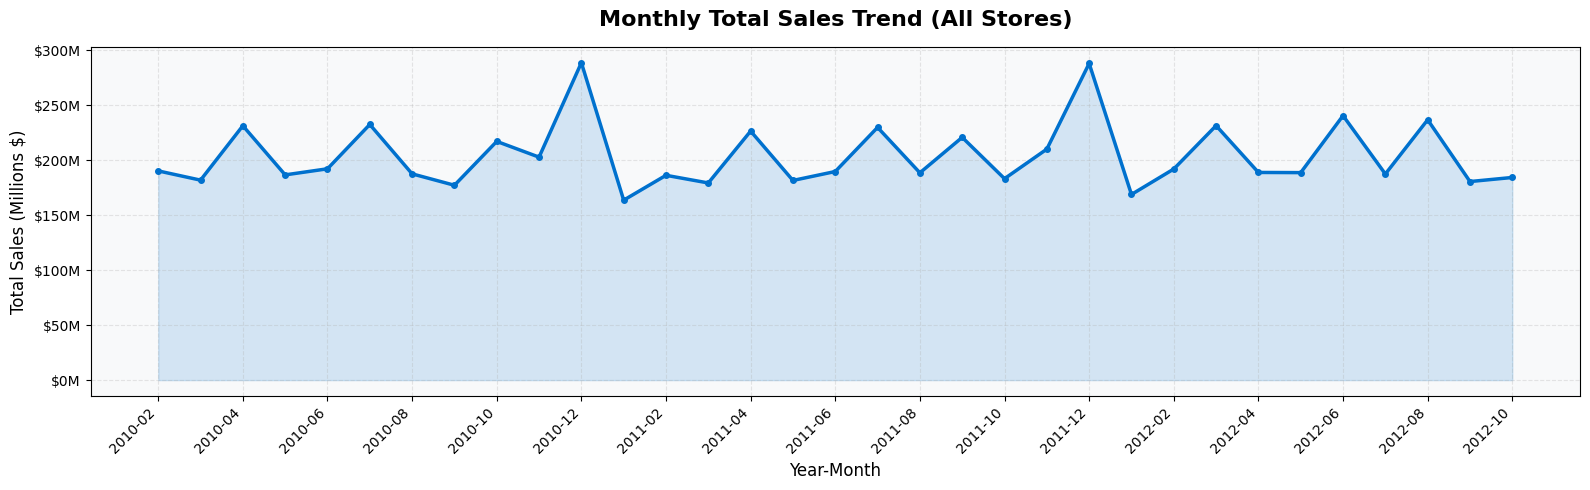

Visualization 2 saved ✅


In [ ]:
# ── Visualization 2: Monthly Sales Trend ──
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(pd_monthly['Month_Label'], pd_monthly['Total_Sales'] / 1e6,
        color='#0071CE', linewidth=2.5, marker='o', markersize=4)
ax.fill_between(range(len(pd_monthly)), pd_monthly['Total_Sales'] / 1e6,
                alpha=0.15, color='#0071CE')
ax.set_title('Monthly Total Sales Trend (All Stores)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Year-Month', fontsize=12)
ax.set_ylabel('Total Sales (Millions $)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
tick_step = max(1, len(pd_monthly) // 12)
ax.set_xticks(range(0, len(pd_monthly), tick_step))
ax.set_xticklabels(pd_monthly['Month_Label'][::tick_step], rotation=45, ha='right')
ax.grid(alpha=0.3, linestyle='--')
ax.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.savefig('viz2_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 2 saved ✅")

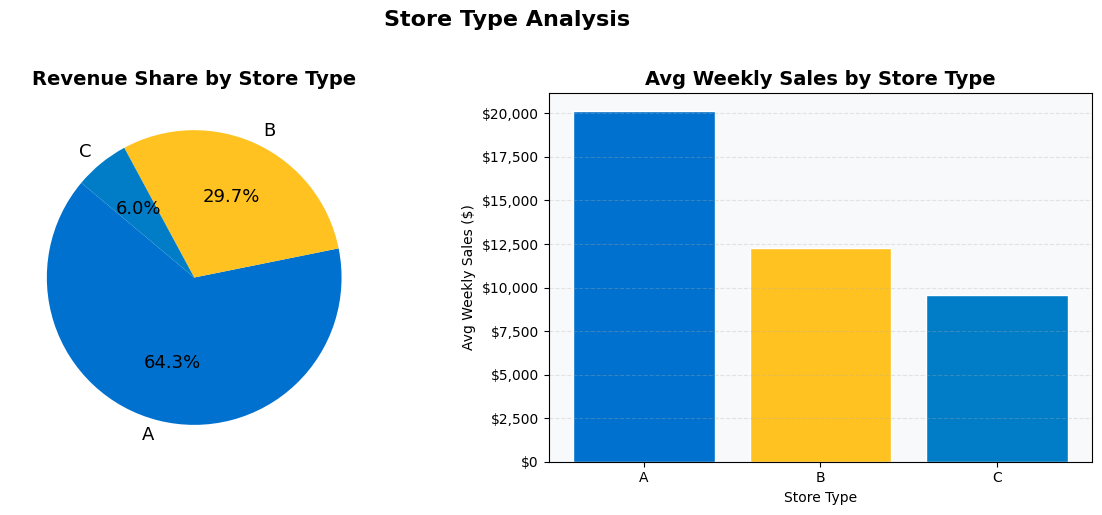

Visualization 3 saved ✅


In [ ]:
# ── Visualization 3: Sales by Store Type ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

walmart_colors = ['#0071CE', '#FFC220', '#007DC6']

# Pie chart
axes[0].pie(pd_type_sales['Total_Sales'], labels=pd_type_sales['Type'],
            autopct='%1.1f%%', colors=walmart_colors,
            startangle=140, textprops={'fontsize': 13})
axes[0].set_title('Revenue Share by Store Type', fontsize=14, fontweight='bold')

# Bar chart — avg sales
axes[1].bar(pd_type_sales['Type'], pd_type_sales['Avg_Sales'],
            color=walmart_colors, edgecolor='white')
axes[1].set_title('Avg Weekly Sales by Store Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Store Type')
axes[1].set_ylabel('Avg Weekly Sales ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].set_facecolor('#f8f9fa')

plt.suptitle('Store Type Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz3_store_type.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 3 saved ✅")

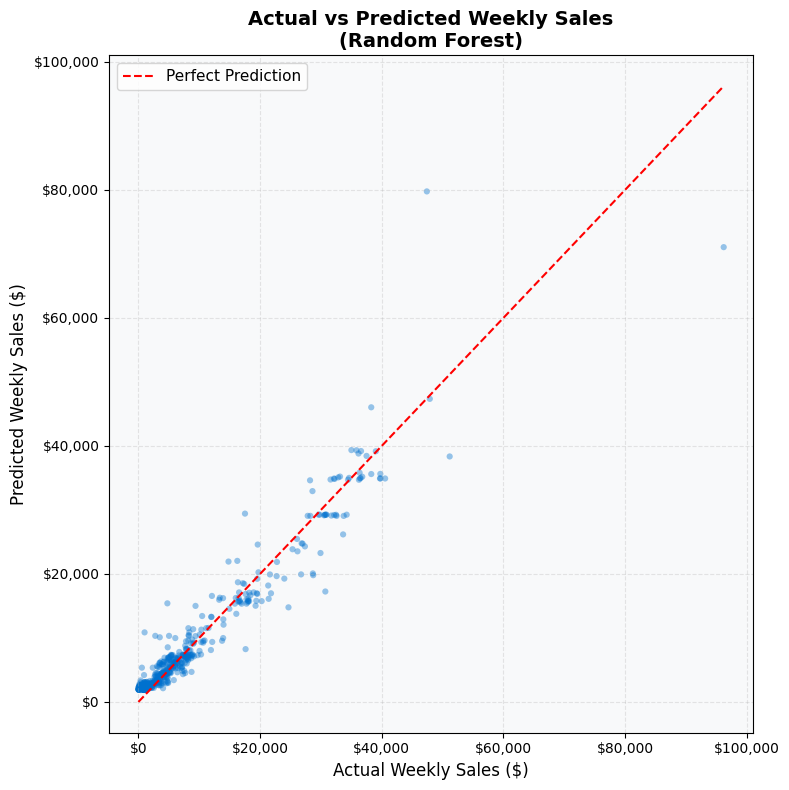

Visualization 4 saved ✅


In [ ]:
# ── Visualization 4: Actual vs Predicted (Random Forest) ──
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(pd_rf_preds['Weekly_Sales'], pd_rf_preds['prediction'],
           alpha=0.4, color='#0071CE', s=20, edgecolors='none')
max_val = max(pd_rf_preds['Weekly_Sales'].max(), pd_rf_preds['prediction'].max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')
ax.set_title('Actual vs Predicted Weekly Sales\n(Random Forest)', fontsize=14, fontweight='bold')
ax.set_xlabel('Actual Weekly Sales ($)', fontsize=12)
ax.set_ylabel('Predicted Weekly Sales ($)', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=11)
ax.grid(alpha=0.3, linestyle='--')
ax.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.savefig('viz4_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 4 saved ✅")

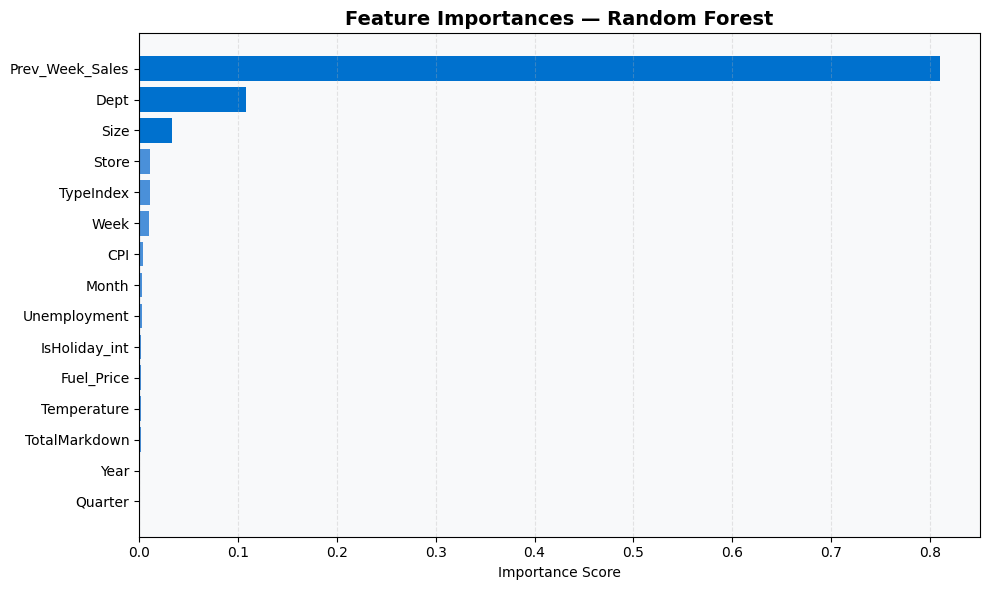

Visualization 5 saved ✅


In [ ]:
# ── Visualization 5: Feature Importances ──
fig, ax = plt.subplots(figsize=(10, 6))
colors_fi = ['#0071CE' if i < 3 else '#4a90d9' for i in range(len(feat_imp))]
ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors_fi)
ax.set_title('Feature Importances — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.savefig('viz5_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 5 saved ✅")

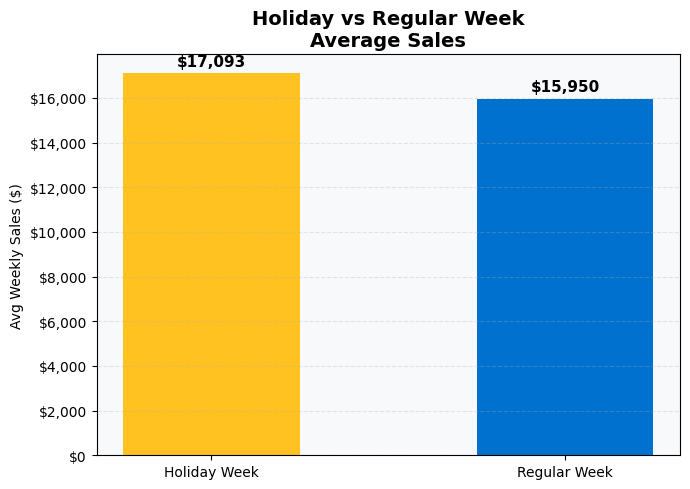

Visualization 6 saved ✅


In [ ]:
# ── Visualization 6: Holiday vs Non-Holiday ──
pd_holiday['Label'] = pd_holiday['IsHoliday'].map({True: 'Holiday Week', False: 'Regular Week'})
fig, ax = plt.subplots(figsize=(7, 5))
bar_colors = ['#FFC220', '#0071CE']
ax.bar(pd_holiday['Label'], pd_holiday['Avg_Sales'], color=bar_colors, width=0.5)
ax.set_title('Holiday vs Regular Week\nAverage Sales', fontsize=14, fontweight='bold')
ax.set_ylabel('Avg Weekly Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_facecolor('#f8f9fa')
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 200,
            f'${bar.get_height():,.0f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('viz6_holiday_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 6 saved ✅")

## 8. Save Processed Dataset

In [ ]:
# ── Save final processed dataset as Parquet ──
output_cols = [
    'Store','Dept','Date','Type','Size','Weekly_Sales',
    'IsHoliday','Temperature','Fuel_Price','CPI','Unemployment',
    'TotalMarkdown','Year','Month','Week','Quarter',
    'TypeIndex','Prev_Week_Sales'
]

df.select(output_cols) \
  .write.mode('overwrite') \
  .parquet('/content/walmart_processed.parquet')

print("Processed dataset saved as Parquet ✅")
print("All pipeline steps completed! 🎉")

Processed dataset saved as Parquet ✅
All pipeline steps completed! 🎉


---
## Summary

| Step | Description | Output |
|------|-------------|--------|
| Data Loading | 3 CSVs loaded via Spark | DataFrames |
| Data Cleaning | Removed negative sales, parsed dates, filled nulls | Clean DataFrame |
| Feature Engineering | Temporal features, lag sales, markdown total, type encoding | Enriched DataFrame |
| Descriptive Analytics | Summary stats, store/type/dept aggregations | Insights |
| Regression — LR | Linear Regression baseline | RMSE, MAE, R² |
| Regression — RF | Random Forest (50 trees) | RMSE, MAE, R² |
| Visualization | 6 charts covering store, time, model performance | PNG files |
| Output | Processed data saved as Parquet | walmart_processed.parquet |
